**LOAD DATA & DATASET OVERVIEW**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving air_quality_health_impact_data..csv to air_quality_health_impact_data..csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('air_quality_health_impact_data..csv')
print("Shape of dataset:", df.shape)
df.shape
print("\n--- Basic Info ---")
df.info()
print("\n--- Summary Statistics ---")
print(df.describe())
print("\nFirst 5 rows:")
print(df.head())
print("\n--- Missing Values ---")
print(df.isnull().sum())

Shape of dataset: (5811, 15)

--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5811 entries, 0 to 5810
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RecordID             5811 non-null   int64  
 1   AQI                  5811 non-null   float64
 2   PM10                 5811 non-null   float64
 3   PM2_5                5811 non-null   float64
 4   NO2                  5811 non-null   float64
 5   SO2                  5811 non-null   float64
 6   O3                   5811 non-null   float64
 7   Temperature          5811 non-null   float64
 8   Humidity             5811 non-null   float64
 9   WindSpeed            5811 non-null   float64
 10  RespiratoryCases     5811 non-null   int64  
 11  CardiovascularCases  5811 non-null   int64  
 12  HospitalAdmissions   5811 non-null   int64  
 13  HealthImpactScore    5811 non-null   float64
 14  HealthImpactClass    5811 non-null   in

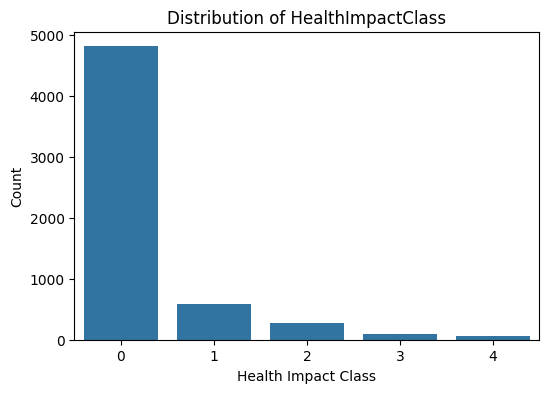

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='HealthImpactClass', data=df)
plt.title('Distribution of HealthImpactClass')
plt.xlabel('Health Impact Class')
plt.ylabel('Count')
plt.show()


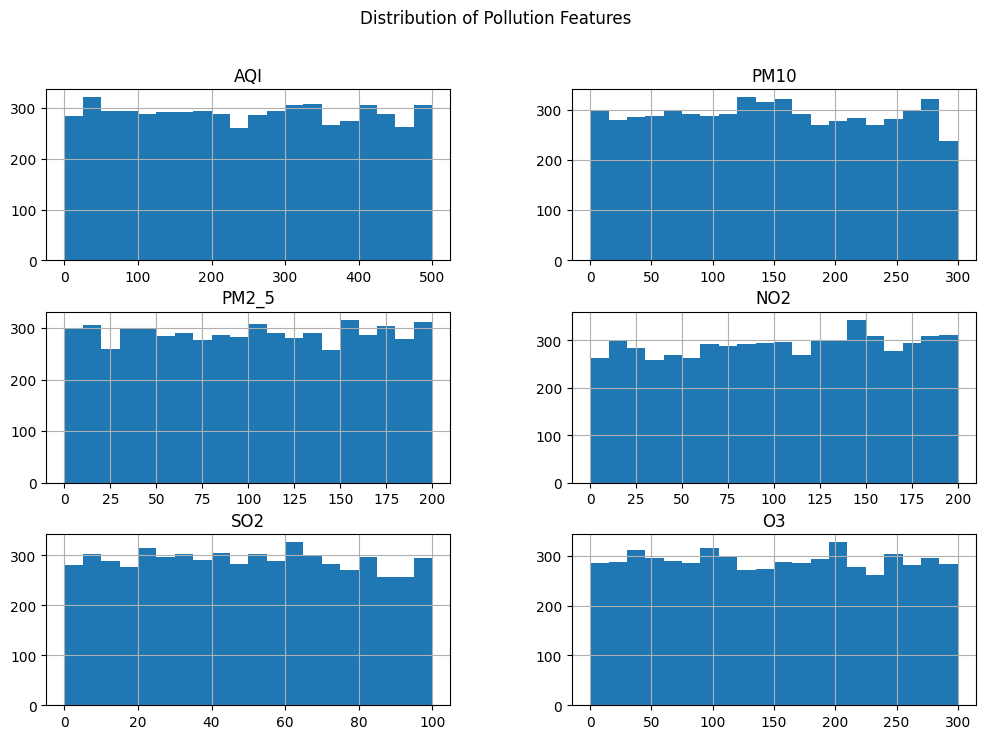

In [ ]:
pollution_cols = ['AQI', 'PM10', 'PM2_5', 'NO2', 'SO2', 'O3']

df[pollution_cols].hist(figsize=(12,8), bins=20)
plt.suptitle('Distribution of Pollution Features')
plt.show()


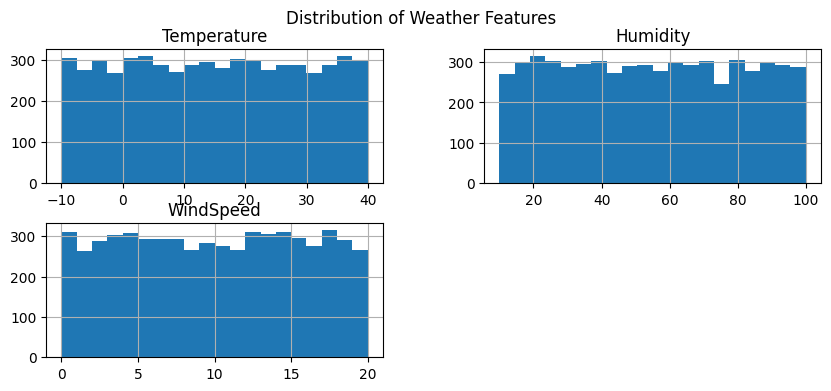

In [ ]:
weather_cols = ['Temperature', 'Humidity', 'WindSpeed']

df[weather_cols].hist(figsize=(10,4), bins=20)
plt.suptitle('Distribution of Weather Features')
plt.show()


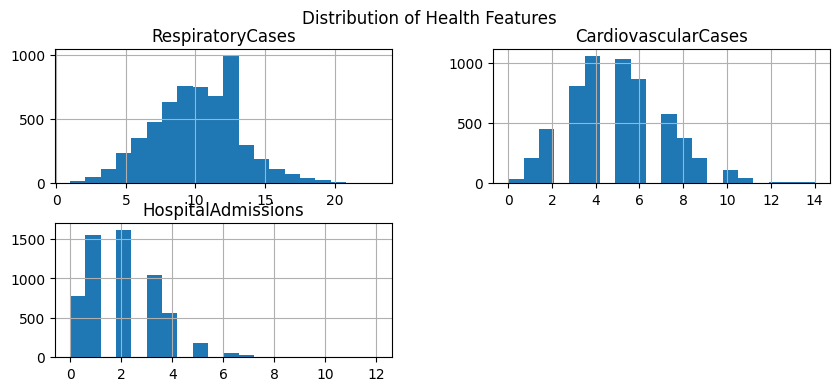

In [ ]:
health_cols = ['RespiratoryCases', 'CardiovascularCases', 'HospitalAdmissions']

df[health_cols].hist(figsize=(10,4), bins=20)
plt.suptitle('Distribution of Health Features')
plt.show()


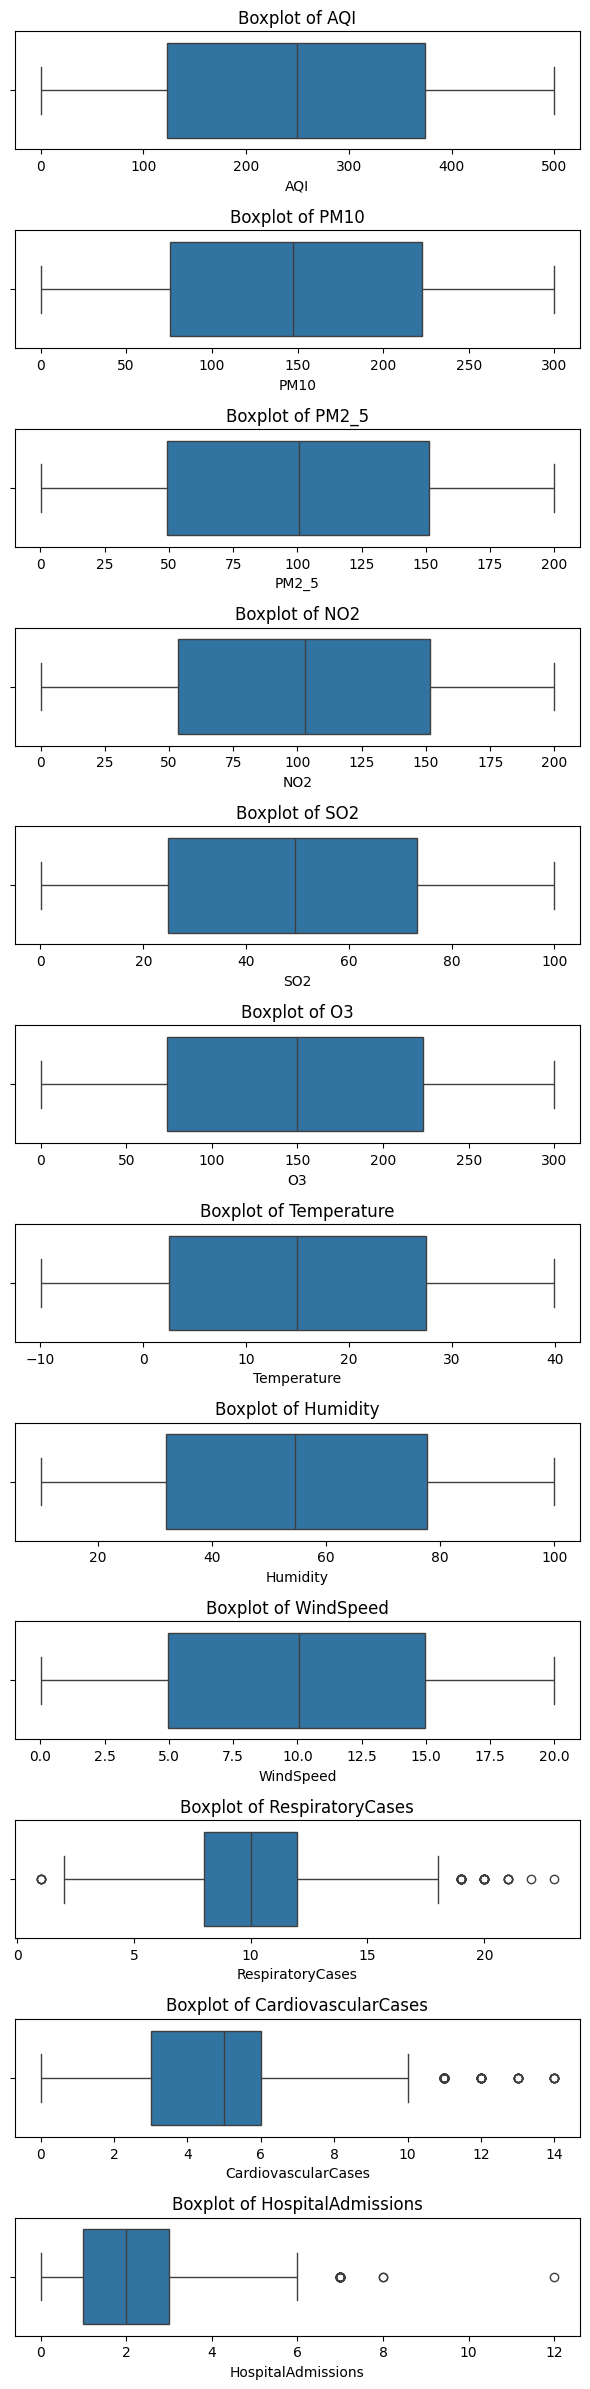

In [ ]:
features = pollution_cols + weather_cols + health_cols

plt.figure(figsize=(6, 2 * len(features)))

for i, col in enumerate(features, 1):
    plt.subplot(len(features), 1, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()


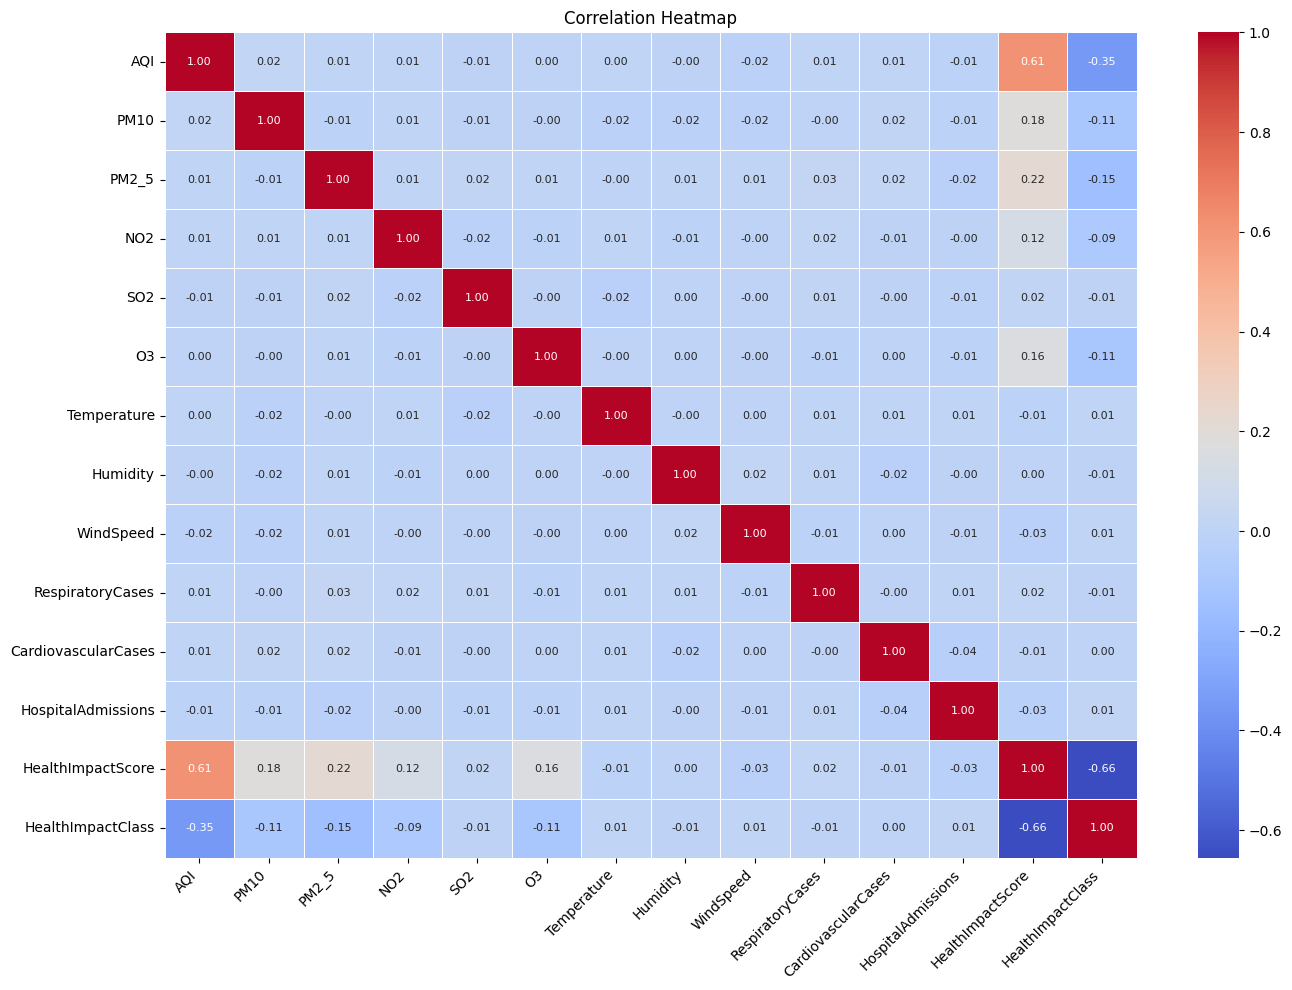

In [ ]:
plt.figure(figsize=(14,10))

corr = df.drop(columns=['RecordID']).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


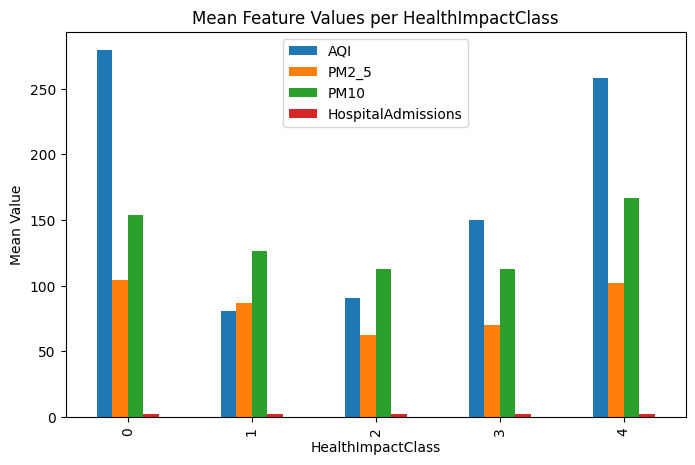

In [ ]:
class_means = df.groupby('HealthImpactClass')[[
    'AQI', 'PM2_5', 'PM10', 'HospitalAdmissions'
]].mean()

class_means.plot(kind='bar', figsize=(8,5))
plt.title('Mean Feature Values per HealthImpactClass')
plt.ylabel('Mean Value')
plt.show()


In [ ]:
skewness = df.select_dtypes(include='number').skew()
print("Skewness of numerical features:")
print(skewness)


Skewness of numerical features:
RecordID               0.000000
AQI                    0.010608
PM10                   0.019243
PM2_5                 -0.002834
NO2                   -0.053589
SO2                    0.025574
O3                     0.011182
Temperature            0.004898
Humidity               0.023063
WindSpeed             -0.011078
RespiratoryCases       0.255866
CardiovascularCases    0.445664
HospitalAdmissions     0.715323
HealthImpactScore     -2.350709
HealthImpactClass      2.971374
dtype: float64


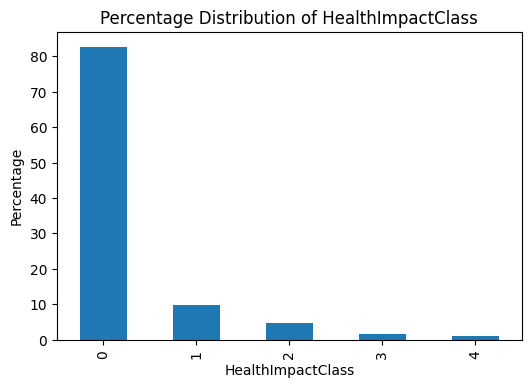

In [ ]:
class_percent = df['HealthImpactClass'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
class_percent.plot(kind='bar')
plt.title('Percentage Distribution of HealthImpactClass')
plt.ylabel('Percentage')
plt.show()


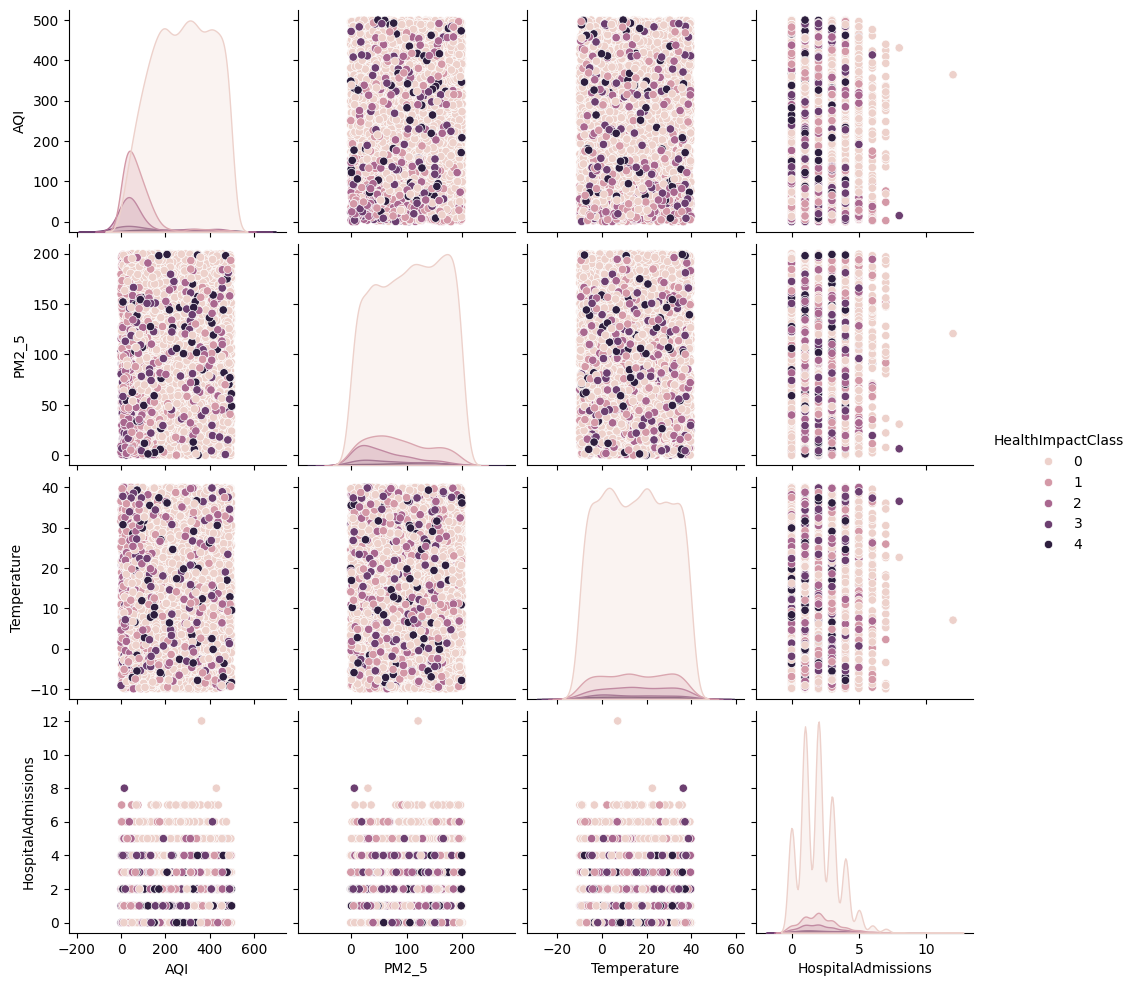

In [ ]:
sns.pairplot(
    df[['AQI', 'PM2_5', 'Temperature', 'HospitalAdmissions', 'HealthImpactClass']],
    hue='HealthImpactClass'
)
plt.show()


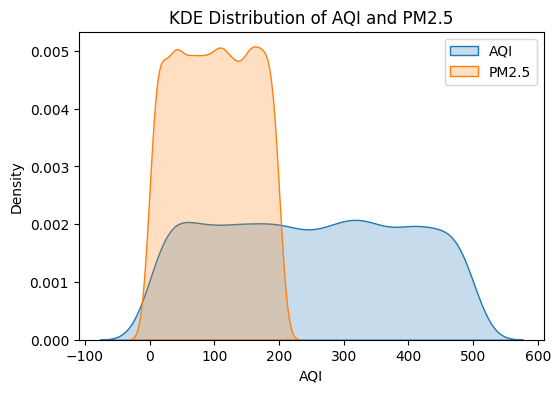

In [ ]:
plt.figure(figsize=(6,4))
sns.kdeplot(df['AQI'], label='AQI', fill=True)
sns.kdeplot(df['PM2_5'], label='PM2.5', fill=True)
plt.title('KDE Distribution of AQI and PM2.5')
plt.legend()
plt.show()


In [ ]:
df_fe = df.drop(columns=['HealthImpactScore', 'RecordID'])
print(df_fe.shape)


(5811, 13)


In [ ]:
df_fe['TotalPollution'] = (
    df_fe['PM2_5'] + df_fe['PM10'] +
    df_fe['NO2'] + df_fe['SO2'] + df_fe['O3']
)

df_fe['PM_Ratio'] = df_fe['PM2_5'] / (df_fe['PM10'] + 1)


In [ ]:
df_fe['PM25_Temp'] = df_fe['PM2_5'] * df_fe['Temperature']
df_fe['PM25_Humidity'] = df_fe['PM2_5'] * df_fe['Humidity']
df_fe['AQI_Wind'] = df_fe['AQI'] / (df_fe['WindSpeed'] + 1)


In [ ]:
df_fe['TotalHealthCases'] = (
    df_fe['RespiratoryCases'] + df_fe['CardiovascularCases']
)

df_fe['AdmissionRate'] = (
    df_fe['HospitalAdmissions'] / (df_fe['TotalHealthCases'] + 1)
)


In [ ]:
df_fe['AQI_Bin'] = pd.cut(
    df_fe['AQI'],
    bins=[0, 50, 100, 200, 500],
    labels=['Good', 'Moderate', 'Poor', 'Severe']
)

df_fe['Temp_Bin'] = pd.cut(
    df_fe['Temperature'],
    bins=[-10, 15, 30, 50],
    labels=['Cold', 'Normal', 'Hot']
)

df_fe['Humidity_Bin'] = pd.cut(
    df_fe['Humidity'],
    bins=[0, 30, 60, 100],
    labels=['Low', 'Medium', 'High']
)


In [ ]:
df_fe = pd.get_dummies(
    df_fe,
    columns=['AQI_Bin', 'Temp_Bin', 'Humidity_Bin'],
    drop_first=True
)


In [ ]:
print("Final shape after feature engineering:", df_fe.shape)
df_fe.head()


Final shape after feature engineering: (5811, 27)


,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,...,AQI_Wind,TotalHealthCases,AdmissionRate,AQI_Bin_Moderate,AQI_Bin_Poor,AQI_Bin_Severe,Temp_Bin_Normal,Temp_Bin_Hot,Humidity_Bin_Medium,Humidity_Bin_High
0,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,...,26.236547,12,0.076923,False,True,False,False,False,False,True
1,475.357153,246.254703,9.984497,16.318326,90.499523,169.621727,1.543378,46.851415,4.521422,10,...,86.093255,12,0.000000,False,False,True,False,False,True,False
2,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,...,30.104913,16,0.000000,False,False,True,False,False,False,False
3,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,...,18.360942,16,0.058824,False,False,True,True,False,False,True
4,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,...,5.021607,9,0.100000,True,False,False,False,False,False,False


**Training**

In [ ]:
X = df_fe.drop(columns=['HealthImpactClass'])
y = df_fe['HealthImpactClass']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
classes = np.unique(y_train_smote)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_smote
)

class_weight_dict = dict(zip(classes, class_weights))
sample_weights = np.array([class_weight_dict[y] for y in y_train_smote])


XGBoost

In [ ]:
from xgboost import XGBClassifier


# -----------------------------
# Define XGBoost model
# -----------------------------
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42
)

# -----------------------------
# Hyperparameter grid for tuning
# -----------------------------
params = {
    'n_estimators': [300, 500],
    'max_depth': [6, 8],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# -----------------------------
# GridSearchCV
# -----------------------------
gs = GridSearchCV(
    xgb,
    params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# -----------------------------
# Fit GridSearch with sample weights
# -----------------------------
gs.fit(X_train_smote, y_train_smote, sample_weight=sample_weights)

# -----------------------------
# Predict on test set
# -----------------------------
y_pred = gs.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
print("Best Parameters:", gs.best_params_)
print(classification_report(y_test, y_pred))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='magma')
plt.title("XGBoost Confusion Matrix (SMOTE + Class Weights)")
plt.show()


KeyboardInterrupt: 

Random forest

In [ ]:
# =============================
# 1. Import Random Forest Classifier
# =============================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =============================
# 2. Define Random Forest Model
# =============================
rf = RandomForestClassifier(random_state=42)

# =============================
# 3. Hyperparameter Grid for Tuning
# =============================
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8, None]
}

# =============================
# 4. GridSearchCV
# =============================
rf_gs = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# =============================
# 5. Train Model
# =============================
rf_gs.fit(X_train_smote, y_train_smote, sample_weight=sample_weights)

# =============================
# 6. Prediction on Test Data
# =============================
rf_pred = rf_gs.predict(X_test)

# =============================
# 7. Model Evaluation
# =============================
print("Random Forest Best Params:", rf_gs.best_params_)
print(classification_report(y_test, rf_pred))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt='d'
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Descision tree



In [ ]:
# =============================
# 1. Import Decision Tree Classifier
# =============================
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =============================
# 2. Define Decision Tree Model
# =============================
dt = DecisionTreeClassifier(random_state=42)

# =============================
# 3. Hyperparameter Grid for Tuning
# =============================
dt_params = {
    'max_depth': [6, 8, None],
    'min_samples_split': [2, 5]
}

# =============================
# 4. GridSearchCV
# =============================
dt_gs = GridSearchCV(
    dt,
    dt_params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# =============================
# 5. Train Model
# =============================
dt_gs.fit(X_train_smote, y_train_smote, sample_weight=sample_weights)

# =============================
# 6. Prediction on Test Data
# =============================
dt_pred = dt_gs.predict(X_test)

# =============================
# 7. Model Evaluation
# =============================
print("Decision Tree Best Params:", dt_gs.best_params_)
print(classification_report(y_test, dt_pred))

sns.heatmap(
    confusion_matrix(y_test, dt_pred),
    annot=True,
    fmt='d'
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


knn

In [ ]:
# =============================
# 1. Import K-Nearest Neighbors Classifier
# =============================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =============================
# 2. Define KNN Model
# =============================
knn = KNeighborsClassifier()

# =============================
# 3. Hyperparameter Grid for Tuning
# =============================
knn_params = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

# =============================
# 4. GridSearchCV
# =============================
knn_gs = GridSearchCV(
    knn,
    knn_params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# =============================
# 5. Train Model
# =============================
knn_gs.fit(X_train_smote, y_train_smote)

# =============================
# 6. Prediction on Test Data
# =============================
knn_pred = knn_gs.predict(X_test)

# =============================
# 7. Model Evaluation
# =============================
print("KNN Best Params:", knn_gs.best_params_)
print(classification_report(y_test, knn_pred))

sns.heatmap(
    confusion_matrix(y_test, knn_pred),
    annot=True,
    fmt='d'
)
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


AdaBoost

In [ ]:
# =============================
# 1. Import AdaBoost Classifier
# =============================
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =============================
# 2. Define AdaBoost Model
# =============================
ada = AdaBoostClassifier(random_state=42)

# =============================
# 3. Hyperparameter Grid for Tuning
# =============================
ada_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.5, 1.0]
}

# =============================
# 4. GridSearchCV
# =============================
ada_gs = GridSearchCV(
    ada,
    ada_params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# =============================
# 5. Train Model
# =============================
ada_gs.fit(X_train_smote, y_train_smote, sample_weight=sample_weights)

# =============================
# 6. Prediction on Test Data
# =============================
ada_pred = ada_gs.predict(X_test)

# =============================
# 7. Model Evaluation
# =============================
print("AdaBoost Best Params:", ada_gs.best_params_)
print(classification_report(y_test, ada_pred))

sns.heatmap(
    confusion_matrix(y_test, ada_pred),
    annot=True,
    fmt='d'
)
plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


**Merge HealthImpactClass 3 & 4**

In [ ]:
# Merge class 3 & 4
y_train_merged = y_train_smote.replace({4: 3})
y_test_merged = y_test.replace({4: 3})

# Recompute class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_merged)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_merged
)
class_weight_dict = dict(zip(classes, class_weights))
sample_weights = np.array([class_weight_dict[y] for y in y_train_merged])


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


XGBoost

XGBoost Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 500, 'subsample': 0.8}
XGBoost Results:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       962
           1       0.79      0.77      0.78       116
           2       0.70      0.69      0.70        55
           3       0.64      0.30      0.41        30

    accuracy                           0.93      1163
   macro avg       0.77      0.68      0.71      1163
weighted avg       0.92      0.93      0.92      1163



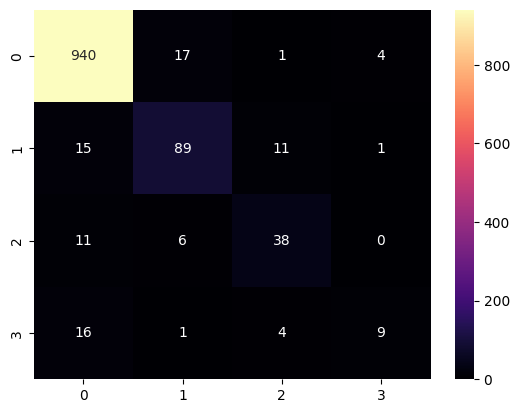

In [ ]:
from xgboost import XGBClassifier


xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,      # now 0,1,2,3
    eval_metric='mlogloss',
    random_state=42,
    tree_method='hist'
)

params = {
    'n_estimators': [300, 500],
    'max_depth': [6, 8],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

gs_xgb = GridSearchCV(
    xgb,
    params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

gs_xgb.fit(X_train_smote, y_train_merged, sample_weight=sample_weights)

print("XGBoost Best Params:", gs_xgb.best_params_)


y_pred_xgb = gs_xgb.predict(X_test)

print("XGBoost Results:")
print(classification_report(y_test_merged, y_pred_xgb))
sns.heatmap(confusion_matrix(y_test_merged, y_pred_xgb), annot=True, fmt='d', cmap='magma')
plt.show()


Random Forest

Random Forest Best Params: {'max_depth': None, 'n_estimators': 200}
Random Forest Results:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       962
           1       0.75      0.81      0.78       116
           2       0.73      0.69      0.71        55
           3       0.50      0.27      0.35        30

    accuracy                           0.92      1163
   macro avg       0.73      0.68      0.70      1163
weighted avg       0.92      0.92      0.92      1163



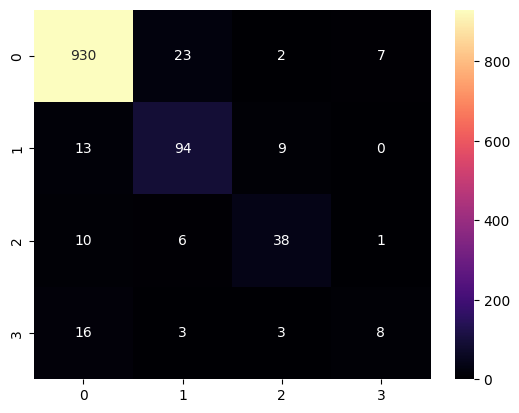

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

params_rf = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8, None]
}

gs_rf = GridSearchCV(
    rf,
    params_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

gs_rf.fit(X_train_smote, y_train_merged, sample_weight=sample_weights)

print("Random Forest Best Params:", gs_rf.best_params_)


y_pred_rf = gs_rf.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test_merged, y_pred_rf))
sns.heatmap(confusion_matrix(y_test_merged, y_pred_rf), annot=True, fmt='d', cmap='magma')
plt.show()


Decision Tree

Decision Tree Best Params: {'max_depth': None, 'min_samples_split': 2}
Decision Tree Results:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91       962
           1       0.65      0.64      0.64       116
           2       0.42      0.64      0.50        55
           3       0.11      0.27      0.16        30

    accuracy                           0.83      1163
   macro avg       0.53      0.60      0.55      1163
weighted avg       0.87      0.83      0.85      1163



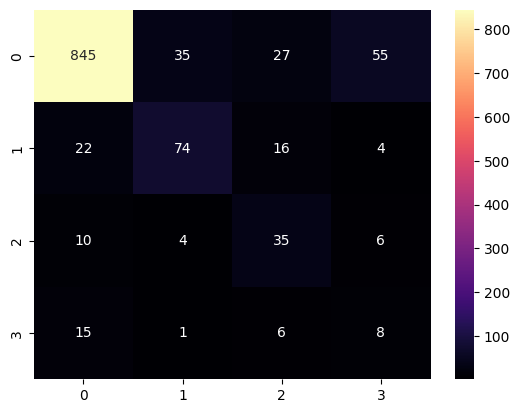

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

params_dt = {
    'max_depth': [6, 8, None],
    'min_samples_split': [2, 5]
}

gs_dt = GridSearchCV(
    dt,
    params_dt,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

gs_dt.fit(X_train_smote, y_train_merged, sample_weight=sample_weights)

print("Decision Tree Best Params:", gs_dt.best_params_)

y_pred_dt = gs_dt.predict(X_test)

print("Decision Tree Results:")
print(classification_report(y_test_merged, y_pred_dt))
sns.heatmap(confusion_matrix(y_test_merged, y_pred_dt), annot=True, fmt='d', cmap='magma')
plt.show()


K-Nearest Neighbors

KNN Best Params: {'n_neighbors': 3, 'weights': 'distance'}
KNN Results:
              precision    recall  f1-score   support

           0       0.92      0.55      0.68       962
           1       0.22      0.34      0.27       116
           2       0.12      0.22      0.15        55
           3       0.02      0.20      0.04        30

    accuracy                           0.50      1163
   macro avg       0.32      0.33      0.29      1163
weighted avg       0.79      0.50      0.60      1163



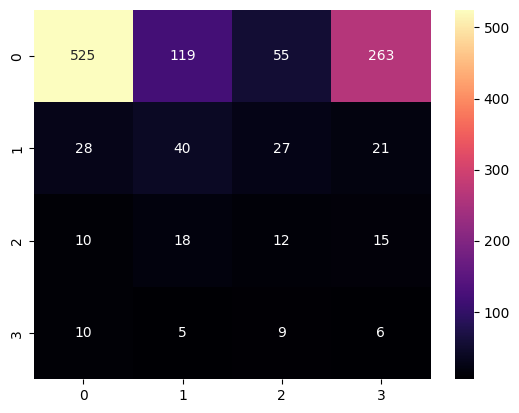

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

params_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

gs_knn = GridSearchCV(
    knn,
    params_knn,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

gs_knn.fit(X_train_smote, y_train_merged)

print("KNN Best Params:", gs_knn.best_params_)

y_pred_knn = gs_knn.predict(X_test)

print("KNN Results:")
print(classification_report(y_test_merged, y_pred_knn))
sns.heatmap(confusion_matrix(y_test_merged, y_pred_knn), annot=True, fmt='d', cmap='magma')
plt.show()


AdaBoost

AdaBoost Best Para ms: {'learning_rate': 0.5, 'n_estimators': 100}
AdaBoost Results:
              precision    recall  f1-score   support

           0       0.96      0.64      0.77       962
           1       0.31      0.63      0.41       116
           2       0.51      0.73      0.60        55
           3       0.01      0.07      0.02        30

    accuracy                           0.63      1163
   macro avg       0.45      0.51      0.45      1163
weighted avg       0.85      0.63      0.70      1163



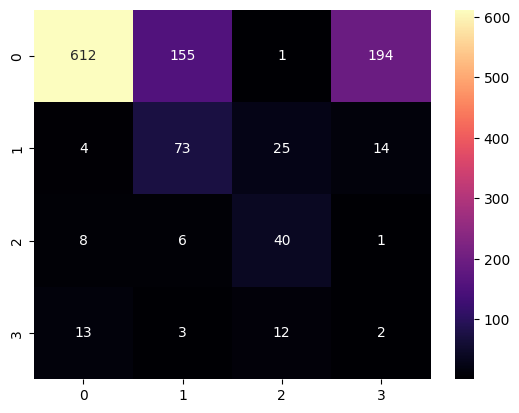

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(random_state=42)

params_ada = {
    'n_estimators': [50, 100],
    'learning_rate': [0.5, 1.0]
}

gs_ada = GridSearchCV(
    ada,
    params_ada,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

gs_ada.fit(X_train_smote, y_train_merged, sample_weight=sample_weights)

print("AdaBoost Best Para ms:", gs_ada.best_params_)

y_pred_ada = gs_ada.predict(X_test)

print("AdaBoost Results:")
print(classification_report(y_test_merged, y_pred_ada))
sns.heatmap(confusion_matrix(y_test_merged, y_pred_ada), annot=True, fmt='d', cmap='magma')
plt.show()


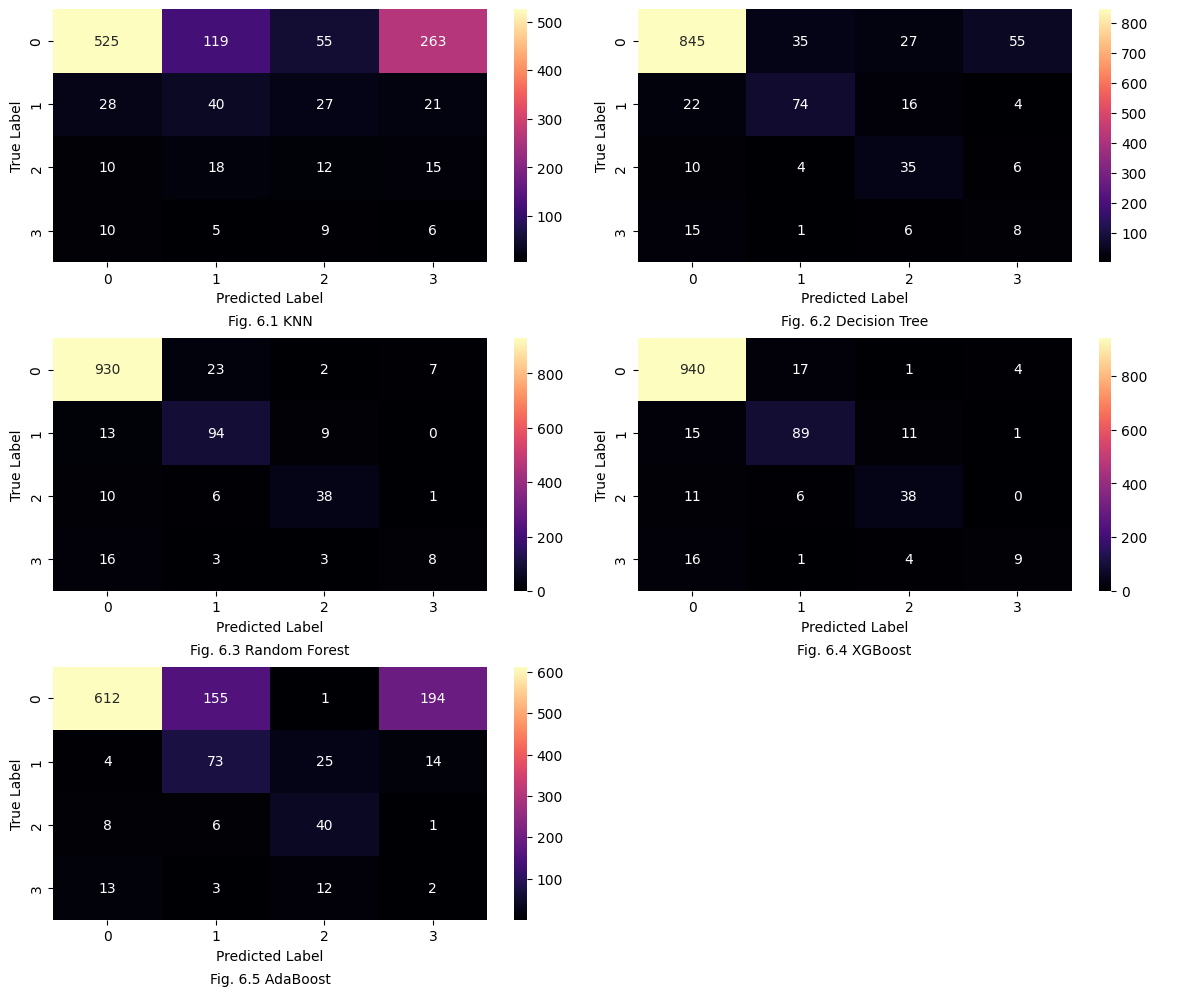

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrices
cm_knn = confusion_matrix(y_test_merged, y_pred_knn)
cm_dt = confusion_matrix(y_test_merged, y_pred_dt)
cm_rf = confusion_matrix(y_test_merged, y_pred_rf)
cm_xgb = confusion_matrix(y_test_merged, y_pred_xgb)
cm_ada = confusion_matrix(y_test_merged, y_pred_ada)

# Create layout
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

models = [
    ("Fig. 6.1 KNN", cm_knn),
    ("Fig. 6.2 Decision Tree", cm_dt),
    ("Fig. 6.3 Random Forest", cm_rf),
    ("Fig. 6.4 XGBoost", cm_xgb),
    ("Fig. 6.5 AdaBoost", cm_ada)
]

for i, (caption, cm) in enumerate(models):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='magma',
        ax=axes[i]
    )
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")

    # Add caption BELOW each plot
    axes[i].text(
        0.5, -0.25, caption,
        transform=axes[i].transAxes,
        ha='center',
        fontsize=10
    )

# Hide last empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig("/content/cmetrics.pdf")
plt.show()

from google.colab import files
files.download("/content/cmetrics.pdf")
